In [103]:
import pandas as pd
import kagglehub

path = r"C:\Users\jli66\OneDrive\Documents\NBA Betting project\kagglehub\datasets\chevronronson\nba-stats-dataset\versions\56"

print("Path to dataset files:", path)

games = pd.read_csv(f"{path}/csv/games_index.csv")
odds = pd.read_csv(f"{path}/csv/game_odds.csv")

print(games.shape, games.columns.tolist())
print(odds.shape, odds.columns.tolist())
games.head()
# odds.head()

Path to dataset files: C:\Users\jli66\OneDrive\Documents\NBA Betting project\kagglehub\datasets\chevronronson\nba-stats-dataset\versions\56
(38023, 17) ['game_id', 'game_date', 'season_year', 'matchup', 'home', 'away', 'team_id_home', 'team_id_away', 'team_name_home', 'team_name_away', 'winner', 'pts_home', 'pts_away', 'margin', 'min', 'odds_home', 'odds_away']
(514660, 9) ['game_id', 'game_date', 'odds_date', 'last_fetched', 'decimal_home', 'decimal_away', 'moneyline_home', 'moneyline_away', 'source_url']


,game_id,game_date,season_year,matchup,home,away,team_id_home,team_id_away,team_name_home,team_name_away,winner,pts_home,pts_away,margin,min,odds_home,odds_away
0,42500405,2026-06-13T00:00:00,2025-26,NYK @ SAS,SAS,NYK,1610612759,1610612752,San Antonio Spurs,New York Knicks,NYK,90,94,4,48.0,0.0,0.0
1,42500404,2026-06-10T00:00:00,2025-26,SAS @ NYK,NYK,SAS,1610612752,1610612759,New York Knicks,San Antonio Spurs,NYK,107,106,1,48.0,0.0,0.0
2,42500403,2026-06-08T00:00:00,2025-26,SAS @ NYK,NYK,SAS,1610612752,1610612759,New York Knicks,San Antonio Spurs,SAS,111,115,4,48.0,0.0,0.0
3,42500402,2026-06-05T00:00:00,2025-26,NYK @ SAS,SAS,NYK,1610612759,1610612752,San Antonio Spurs,New York Knicks,NYK,104,105,1,48.0,0.0,0.0
4,42500401,2026-06-03T00:00:00,2025-26,NYK @ SAS,SAS,NYK,1610612759,1610612752,San Antonio Spurs,New York Knicks,NYK,95,105,10,48.0,0.0,0.0


In [ ]:
# Merge in opening odds lines from game_odds.csv. Opening lines are used (rather than closing)
# because they're a price a bettor could actually act on in real time -- the closing line, by
# definition, is only known at the last moment before betting on the game closes.
# odds_date has literal "open"/"close" marker rows per game_id (one of each), plus separate
# timestamped snapshots for line movement that aren't needed here.
opening_odds = odds[odds["odds_date"] == "open"][
    ["game_id", "decimal_home", "decimal_away", "moneyline_home", "moneyline_away"]
]

games_clean = games.merge(opening_odds, on="game_id", how="left", validate="one_to_one")

print(f"{games_clean['decimal_home'].isna().sum()} / {len(games_clean)} games missing an opening line")
games_clean.head(20)


In [105]:
import numpy as np
import pybettor as pb

# Compute de-vigged implied win probabilities per game.
# pb.implied_prob needs both odds of a market together (method="basic" normalizes
# home+away to sum to 1, removing the sportsbook's vig) -> must run row by row.
def row_implied_prob(row):
    if pd.isna(row["decimal_home"]) or pd.isna(row["decimal_away"]):
        return pd.Series({"implied_home": np.nan, "implied_away": np.nan})
    result = pb.implied_prob(
        [row["decimal_home"], row["decimal_away"]],
        category="dec",
        method="basic",
    )
    home_p, away_p = result["implied_prob"]
    return pd.Series({"implied_home": home_p, "implied_away": away_p})

games_clean[["implied_home", "implied_away"]] = games_clean.apply(row_implied_prob, axis=1)

games_clean[["game_id", "matchup", "decimal_home", "decimal_away", "implied_home", "implied_away"]].head(20)


,game_id,matchup,decimal_home,decimal_away,implied_home,implied_away
0,42500405,NYK @ SAS,NaN,NaN,NaN,NaN
1,42500404,SAS @ NYK,NaN,NaN,NaN,NaN
2,42500403,SAS @ NYK,NaN,NaN,NaN,NaN
3,42500402,NYK @ SAS,NaN,NaN,NaN,NaN
4,42500401,NYK @ SAS,NaN,NaN,NaN,NaN
5,42500317,SAS @ OKC,NaN,NaN,NaN,NaN
6,42500316,OKC @ SAS,NaN,NaN,NaN,NaN
7,42500315,SAS @ OKC,NaN,NaN,NaN,NaN
8,42500304,NYK @ CLE,NaN,NaN,NaN,NaN
9,42500314,OKC @ SAS,NaN,NaN,NaN,NaN


In [106]:
# Benchmark Model: Evaluate the implied probabilities against actual game outcomes to see how well they predict results.
import sklearn as sk

# gamesclean has the actual game results in the "home_win" column (1 if home team won, 0 if away team won).

games_clean["home_win"] = (games_clean["pts_home"] > games_clean["pts_away"]).astype(int)


# quantify market prediction as win or loss based on implied probability threshold of 0.5 (50%).

games_clean["market_pred"] = np.where(games_clean["implied_home"] > 0.5, 1, np.where(games_clean["implied_home"].isna(), np.nan, 0)).astype(float)

# accuracy
scored = games_clean.dropna(subset=["implied_home"])
accuracy = sk.metrics.accuracy_score(scored["market_pred"], scored["home_win"])
print(f"Market prediction accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# brier score
brier = sk.metrics.brier_score_loss(scored["home_win"], scored["implied_home"])
print(f"Market Brier score: {brier:.4f}")

# log-loss
logloss = sk.metrics.log_loss(scored["home_win"], scored["implied_home"])
print(f"Market log-loss: {logloss:.4f}")

games_clean[["game_id", "matchup", "pts_home", "pts_away", "home_win", "market_pred", "implied_home", "implied_away"]].head(20)


Market prediction accuracy: 0.6809 (68.09%)
Market Brier score: 0.2043
Market log-loss: 0.5941


,game_id,matchup,pts_home,pts_away,home_win,market_pred,implied_home,implied_away
0,42500405,NYK @ SAS,90,94,0,NaN,NaN,NaN
1,42500404,SAS @ NYK,107,106,1,NaN,NaN,NaN
2,42500403,SAS @ NYK,111,115,0,NaN,NaN,NaN
3,42500402,NYK @ SAS,104,105,0,NaN,NaN,NaN
4,42500401,NYK @ SAS,95,105,0,NaN,NaN,NaN
5,42500317,SAS @ OKC,103,111,0,NaN,NaN,NaN
6,42500316,OKC @ SAS,118,91,1,NaN,NaN,NaN
7,42500315,SAS @ OKC,127,114,1,NaN,NaN,NaN
8,42500304,NYK @ CLE,93,130,0,NaN,NaN,NaN
9,42500314,OKC @ SAS,103,82,1,NaN,NaN,NaN


   prob_bucket  n_games  avg_predicted  actual_win_rate
(-0.001, 0.05]        3       0.044880         0.333333
   (0.05, 0.1]       89       0.081575         0.146067
   (0.1, 0.15]      302       0.126354         0.205298
   (0.15, 0.2]      555       0.178445         0.185586
   (0.2, 0.25]      871       0.226879         0.238806
   (0.25, 0.3]     1175       0.277390         0.287660
   (0.3, 0.35]     1519       0.326273         0.324556
   (0.35, 0.4]     1882       0.375588         0.399575
   (0.4, 0.45]     1910       0.425083         0.415183
   (0.45, 0.5]     1705       0.473052         0.483871
   (0.5, 0.55]     1694       0.528756         0.528926
   (0.55, 0.6]     2407       0.575412         0.554217
   (0.6, 0.65]     2826       0.625438         0.612880
   (0.65, 0.7]     2783       0.674896         0.664032
   (0.7, 0.75]     2733       0.723926         0.726674
   (0.75, 0.8]     2484       0.773651         0.770531
   (0.8, 0.85]     2079       0.823953         0

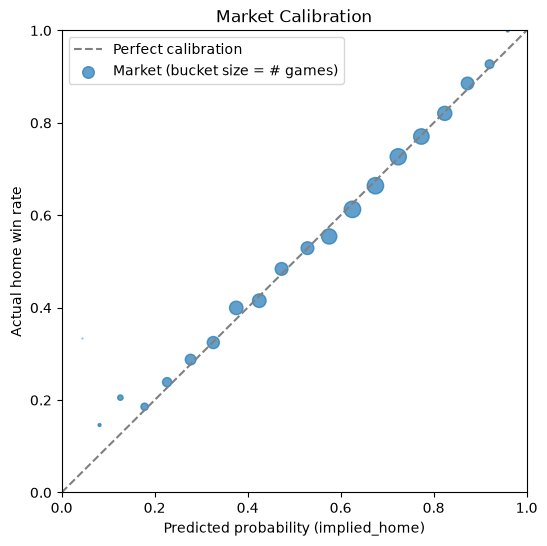

In [107]:
# Calibration check: does "70% implied" actually win ~70% of the time?
import matplotlib.pyplot as plt

bins = np.arange(0, 1.05, 0.05)
scored["prob_bucket"] = pd.cut(scored["implied_home"], bins=bins, include_lowest=True)

calibration = scored.groupby("prob_bucket", observed=True).agg(
    n_games=("home_win", "size"),
    avg_predicted=("implied_home", "mean"),
    actual_win_rate=("home_win", "mean"),
).reset_index()

print(calibration.to_string(index=False))

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.scatter(
    calibration["avg_predicted"],
    calibration["actual_win_rate"],
    s=calibration["n_games"] / 20,
    alpha=0.7,
    label="Market (bucket size = # games)",
)
plt.xlabel("Predicted probability (implied_home)")
plt.ylabel("Actual home win rate")
plt.title("Market Calibration")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()


In [ ]:
# --- Phase B setup: derive season_type from game_id prefix ---
# NBA game_id convention: 1st digit = game type, next 2 digits = season.
# Verified against real season history: 1230 regular-season games/season, with the correct
# COVID-shortened counts in 2019-20/2020-21; 79-87 playoff games/season; play-in totals
# consistent with the format's 2020-21 introduction.
season_type_map = {
    "1": "preseason",
    "2": "regular_season",
    "3": "all_star",
    "4": "playoffs",
    "5": "play_in",
}
games_clean["season_type"] = games_clean["game_id"].astype(str).str[0].map(season_type_map)

print(games_clean["season_type"].value_counts(dropna=False))


In [109]:
# --- Phase B: rest days + leakage-safe rolling team stats (from team_boxscores.csv) ---
team_box = pd.read_csv(f"{path}/csv/team_boxscores.csv")
team_box["game_date"] = pd.to_datetime(team_box["game_date"])
team_box = team_box.sort_values(["team_id", "game_date"]).reset_index(drop=True)

# Rest days since this team's previous game (NaN for each team's first game in the dataset -- no prior game to diff against)
team_box["rest_days"] = team_box.groupby("team_id")["game_date"].diff().dt.days
team_box["is_b2b"] = np.where(team_box["rest_days"].isna(), np.nan, (team_box["rest_days"] <= 1).astype(float))

stat_cols = [
    "pts", "off_rating", "def_rating", "net_rating", "pace",
    "efg_pct", "ts_pct", "oreb_pct", "dreb_pct", "tm_tov_pct", "ast_pct",
]

def leakage_safe_rolling(series, window, min_periods):
    # shift(1) first so a game's "recent form" never includes that game's own stats
    return series.shift(1).rolling(window, min_periods=min_periods).mean()

for col in stat_cols:
    team_box[f"{col}_roll5"] = team_box.groupby("team_id")[col].transform(
        lambda s: leakage_safe_rolling(s, 5, 3)
    )
    team_box[f"{col}_roll10"] = team_box.groupby("team_id")[col].transform(
        lambda s: leakage_safe_rolling(s, 10, 5)
    )

team_box[["team_abbreviation", "game_date", "rest_days", "is_b2b", "pts_roll5", "pts_roll10", "net_rating_roll5"]].head(15)


C:\Users\jli66\AppData\Local\Temp\ipykernel_27912\3074806939.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  team_box["rest_days"] = team_box.groupby("team_id")["game_date"].diff().dt.days
C:\Users\jli66\AppData\Local\Temp\ipykernel_27912\3074806939.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  team_box["is_b2b"] = np.where(team_box["rest_days"].isna(), np.nan, (team_box["rest_days"] <= 1).astype(float))
C:\Users\jli66\AppData\Local\Temp\ipykernel_27912\3074806939.py:20: PerformanceWarning: DataFrame is highly fragment

,team_abbreviation,game_date,rest_days,is_b2b,pts_roll5,pts_roll10,net_rating_roll5
0,ATL,1996-11-01,NaN,NaN,NaN,NaN,NaN
1,ATL,1996-11-02,1.0,1.0,NaN,NaN,NaN
2,ATL,1996-11-04,2.0,0.0,NaN,NaN,NaN
3,ATL,1996-11-05,1.0,1.0,84.333333,NaN,-2.466667
4,ATL,1996-11-07,2.0,0.0,92.500000,NaN,4.075000
5,ATL,1996-11-10,3.0,0.0,92.200000,92.200000,4.400000
6,ATL,1996-11-12,2.0,0.0,93.000000,91.000000,5.640000
7,ATL,1996-11-13,1.0,1.0,94.800000,90.428571,10.000000
8,ATL,1996-11-15,2.0,0.0,93.000000,89.750000,2.120000
9,ATL,1996-11-16,1.0,1.0,86.600000,89.222222,-0.960000


In [ ]:
# --- Injury/absence proxy: minutes "lost" vs. this team's immediately preceding game ---
# player_boxscores.csv only has rows for players who actually played -- a rotation player who
# logged real minutes last game but is entirely absent from this game's box score is a proxy
# for a new injury/inactive designation. That status is normally knowable pre-game via injury
# reports (which is how the market itself prices it) -- we're just recovering it after the
# fact from box-score absence, since this dataset has no separate injury-report table.
MIN_ROTATION_MINUTES = 15

player_box = pd.read_csv(f"{path}/csv/player_boxscores.csv", usecols=["player_id", "team_id", "game_id", "min"])

# Precompute once: which players appeared at all, and which logged rotation-level minutes,
# per (team_id, game_id) -- dict/set lookups instead of re-scanning player_box per row.
all_players_by_team_game = player_box.groupby(["team_id", "game_id"])["player_id"].apply(set)
rotation_by_team_game = (
    player_box[player_box["min"] >= MIN_ROTATION_MINUTES]
    .groupby(["team_id", "game_id"])
    .apply(lambda g: dict(zip(g["player_id"], g["min"])))
)

team_box["prev_game_id"] = team_box.groupby("team_id")["game_id"].shift(1)

def missing_key_minutes(row):
    if pd.isna(row["prev_game_id"]):
        return np.nan
    prev_roster = rotation_by_team_game.get((row["team_id"], int(row["prev_game_id"])), {})
    if not prev_roster:
        return 0.0
    curr_players = all_players_by_team_game.get((row["team_id"], int(row["game_id"])), set())
    return sum(mins for pid, mins in prev_roster.items() if pid not in curr_players)

team_box["missing_key_minutes"] = team_box.apply(missing_key_minutes, axis=1)

team_box[["team_abbreviation", "game_date", "prev_game_id", "missing_key_minutes"]].head(15)


In [ ]:
# --- Reshape team-level rows into one row per game (home_/away_ columns), merge onto games_clean ---
feature_cols = ["rest_days", "is_b2b", "missing_key_minutes"] + [f"{c}_roll5" for c in stat_cols] + [f"{c}_roll10" for c in stat_cols]

# Data quality issue in the source CSV: a handful of games have BOTH teams flagged is_home=0
# (should be one 1 and one 0). Only reshape games where exactly one team is correctly flagged home;
# their rows still count toward other teams' rolling stats, they're just excluded from this merge.
valid_home_games = team_box.groupby("game_id")["is_home"].sum()
valid_home_games = valid_home_games[valid_home_games == 1].index
n_ambiguous = team_box["game_id"].nunique() - len(valid_home_games)
print(f"Excluding {n_ambiguous} games with ambiguous/missing is_home flag from the reshape")

home_features = (
    team_box[(team_box["is_home"] == 1) & (team_box["game_id"].isin(valid_home_games))][["game_id"] + feature_cols]
    .add_suffix("_home")
    .rename(columns={"game_id_home": "game_id"})
)
away_features = (
    team_box[(team_box["is_home"] == 0) & (team_box["game_id"].isin(valid_home_games))][["game_id"] + feature_cols]
    .add_suffix("_away")
    .rename(columns={"game_id_away": "game_id"})
)

game_features = home_features.merge(away_features, on="game_id", how="inner", validate="one_to_one")

games_clean = games_clean.merge(game_features, on="game_id", how="left", validate="one_to_one")

coverage = games_clean["pts_roll5_home"].notna().sum()
print(f"{coverage} / {len(games_clean)} games have full rolling-feature history (needs >=3 prior team games)")

games_clean[[
    "game_id", "matchup", "rest_days_home", "rest_days_away",
    "missing_key_minutes_home", "missing_key_minutes_away",
    "net_rating_roll5_home", "net_rating_roll5_away",
]].head(10)


In [ ]:
# --- Baseline model: build diff features + time-based train/test split ---
diff_stat_cols = ["off_rating", "def_rating", "efg_pct", "ts_pct", "oreb_pct", "dreb_pct", "tm_tov_pct", "ast_pct", "pace"]

dropna_cols = [
    "implied_home",
    "rest_days_home", "rest_days_away", "is_b2b_home", "is_b2b_away",
    "missing_key_minutes_home", "missing_key_minutes_away",
    "net_rating_roll5_home", "net_rating_roll5_away",
    "net_rating_roll10_home", "net_rating_roll10_away",
] + [f"{c}_roll10_home" for c in diff_stat_cols] + [f"{c}_roll10_away" for c in diff_stat_cols]

model_df = games_clean.dropna(subset=dropna_cols).copy()
model_df["game_date"] = pd.to_datetime(model_df["game_date"])

# Home-minus-away differentials, all on the roll10 (stable, longer-run) window -- roll10
# fundamentals carry more predictive weight than roll5 recent form on their own; roll5 is
# used below only to build the momentum signal (recent form relative to that baseline).
for col in diff_stat_cols:
    model_df[f"{col}_roll10_diff"] = model_df[f"{col}_roll10_home"] - model_df[f"{col}_roll10_away"]

model_df["rest_days_diff"] = model_df["rest_days_home"] - model_df["rest_days_away"]
model_df["is_b2b_diff"] = model_df["is_b2b_home"] - model_df["is_b2b_away"]

# Injury/absence proxy: positive = home team lost more rotation minutes to new absences than away did.
model_df["missing_key_minutes_diff"] = model_df["missing_key_minutes_home"] - model_df["missing_key_minutes_away"]

# Momentum: is each team trending better (roll5, recent form) or worse than its own
# longer-run baseline (roll10)? Positive momentum_diff = home team trending up relative to away.
model_df["net_rating_momentum_home"] = model_df["net_rating_roll5_home"] - model_df["net_rating_roll10_home"]
model_df["net_rating_momentum_away"] = model_df["net_rating_roll5_away"] - model_df["net_rating_roll10_away"]
model_df["net_rating_momentum_diff"] = model_df["net_rating_momentum_home"] - model_df["net_rating_momentum_away"]

# drop_first=True: avoid the dummy-variable trap (one season_type category becomes the implicit reference)
model_df = pd.get_dummies(model_df, columns=["season_type"], prefix="season_type", drop_first=True)
season_type_dummy_cols = [c for c in model_df.columns if c.startswith("season_type_")]

# NOTE: off_rating_roll10_diff and def_rating_roll10_diff are used INSTEAD of a
# net_rating_roll10_diff -- net_rating = off_rating - def_rating exactly, so including all
# three would be collinear (net_rating_roll5_diff is dropped for the same reason and is
# recoverable as roll10_diff + momentum_diff). Splitting offense and defense also lets the
# model learn different weights for each, rather than net_rating's built-in assumption that
# they matter equally and oppositely.
numeric_cols_baseline = [f"{c}_roll10_diff" for c in diff_stat_cols] + [
    "net_rating_momentum_diff", "rest_days_diff", "is_b2b_diff", "missing_key_minutes_diff",
]
feature_cols_baseline = numeric_cols_baseline + season_type_dummy_cols

# Time-based split: train through 2021-22, test 2022-23 onward -- never random-split time series data
test_seasons = ["2022-23", "2023-24", "2024-25", "2025-26"]
train_df = model_df[~model_df["season_year"].isin(test_seasons)]
test_df = model_df[model_df["season_year"].isin(test_seasons)]

print(f"Train: {len(train_df)} games ({train_df['game_date'].min().date()} to {train_df['game_date'].max().date()})")
print(f"Test:  {len(test_df)} games ({test_df['game_date'].min().date()} to {test_df['game_date'].max().date()})")
print(f"Features ({len(feature_cols_baseline)}): {feature_cols_baseline}")


In [ ]:
# --- Fit baseline logistic regression, evaluate against the market on the SAME test games ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Fit the scaler on TRAIN only, then apply to both -- fitting on test would leak test-set
# statistics into the transform (same leakage principle as shifting the rolling stats).
scaler = StandardScaler()
train_scaled = train_df.copy()
test_scaled = test_df.copy()
train_scaled[numeric_cols_baseline] = scaler.fit_transform(train_df[numeric_cols_baseline])
test_scaled[numeric_cols_baseline] = scaler.transform(test_df[numeric_cols_baseline])

X_train, y_train = train_scaled[feature_cols_baseline], train_df["home_win"]
X_test, y_test = test_scaled[feature_cols_baseline], test_df["home_win"]

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

test_df = test_df.copy()
test_df["model_prob_home"] = baseline_model.predict_proba(X_test)[:, 1]
test_df["model_pred"] = (test_df["model_prob_home"] > 0.5).astype(int)

model_accuracy = sk.metrics.accuracy_score(y_test, test_df["model_pred"])
model_brier = sk.metrics.brier_score_loss(y_test, test_df["model_prob_home"])
model_logloss = sk.metrics.log_loss(y_test, test_df["model_prob_home"])

# Recompute the market's numbers on this exact test subset (not the full-dataset 0.2043/0.5941/68.09%)
# so the comparison is a fair apples-to-apples head-to-head, not different game populations.
market_accuracy = sk.metrics.accuracy_score(y_test, test_df["market_pred"])
market_brier = sk.metrics.brier_score_loss(y_test, test_df["implied_home"])
market_logloss = sk.metrics.log_loss(y_test, test_df["implied_home"])

print(f"{'Metric':<12} {'Baseline Model':>15} {'Market':>15}")
print(f"{'Accuracy':<12} {model_accuracy:>15.4f} {market_accuracy:>15.4f}")
print(f"{'Brier':<12} {model_brier:>15.4f} {market_brier:>15.4f}")
print(f"{'Log-loss':<12} {model_logloss:>15.4f} {market_logloss:>15.4f}")

pd.Series(baseline_model.coef_[0], index=feature_cols_baseline, name="coefficient").sort_values()


In [ ]:
# --- Try a non-linear model: gradient boosting, on the same features (raw, unscaled) ---
# Tree-based models split on raw thresholds, so scaling doesn't matter here -- use train_df/test_df
# directly rather than the scaled versions built for logistic regression.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

# n_samples > 10_000 so early_stopping="auto" kicks in automatically (holds out part of train
# for its own validation to stop before overfitting) -- no extra config needed for that.
gb_model = HistGradientBoostingClassifier(random_state=42)
gb_model.fit(train_df[feature_cols_baseline], y_train)

test_df["gb_prob_home"] = gb_model.predict_proba(test_df[feature_cols_baseline])[:, 1]
test_df["gb_pred"] = (test_df["gb_prob_home"] > 0.5).astype(int)

gb_accuracy = sk.metrics.accuracy_score(y_test, test_df["gb_pred"])
gb_brier = sk.metrics.brier_score_loss(y_test, test_df["gb_prob_home"])
gb_logloss = sk.metrics.log_loss(y_test, test_df["gb_prob_home"])

print(f"{'Metric':<12} {'Logistic':>12} {'GradBoost':>12} {'Market':>12}")
print(f"{'Accuracy':<12} {model_accuracy:>12.4f} {gb_accuracy:>12.4f} {market_accuracy:>12.4f}")
print(f"{'Brier':<12} {model_brier:>12.4f} {gb_brier:>12.4f} {market_brier:>12.4f}")
print(f"{'Log-loss':<12} {model_logloss:>12.4f} {gb_logloss:>12.4f} {market_logloss:>12.4f}")

# HistGradientBoostingClassifier has no built-in feature_importances_, so use permutation
# importance instead: how much test-set Brier score gets worse when a feature is shuffled.
perm_result = permutation_importance(
    gb_model, test_df[feature_cols_baseline], y_test,
    n_repeats=10, random_state=42, scoring="neg_brier_score",
)
pd.Series(perm_result.importances_mean, index=feature_cols_baseline, name="brier_importance").sort_values(ascending=False)


In [ ]:
# --- Phase C: edge detection -- flag games where our model disagrees with the market ---
# Using the logistic regression model's probabilities: it slightly outperforms gradient
# boosting on this feature set, and gradient boosting showed no non-linear signal worth trading
# the simpler, more interpretable model for.
test_df["edge_home"] = test_df["model_prob_home"] - test_df["implied_home"]

# Backtest: flat 1-unit stake on whichever side (home/away) our model favors more than the
# market does, for games where |edge| clears each threshold. Real payouts via decimal odds.
results = []
for threshold in [0.02, 0.04, 0.06, 0.08, 0.10]:
    bets = test_df[test_df["edge_home"].abs() >= threshold].copy()
    bets["bet_side"] = np.where(bets["edge_home"] > 0, "home", "away")
    bets["odds"] = np.where(bets["bet_side"] == "home", bets["decimal_home"], bets["decimal_away"])
    bets["won"] = np.where(bets["bet_side"] == "home", bets["home_win"] == 1, bets["home_win"] == 0)
    bets["profit"] = np.where(bets["won"], bets["odds"] - 1, -1)

    n_bets = len(bets)
    results.append({
        "threshold": threshold,
        "n_bets": n_bets,
        "win_rate": bets["won"].mean() if n_bets else np.nan,
        "total_profit_units": bets["profit"].sum() if n_bets else np.nan,
        "roi": bets["profit"].sum() / n_bets if n_bets else np.nan,
    })

edge_results = pd.DataFrame(results)
print(edge_results.to_string(index=False))
print(f"\nFor reference, flat-betting every test game with no edge filter: {len(test_df)} bets")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(edge_results["threshold"], edge_results["roi"], marker="o")
ax1.axhline(0, color="gray", linestyle="--")
ax1.set_xlabel("Edge threshold")
ax1.set_ylabel("ROI (per unit staked)")
ax1.set_title("ROI vs. edge threshold")

ax2.bar(edge_results["threshold"].astype(str), edge_results["n_bets"])
ax2.set_xlabel("Edge threshold")
ax2.set_ylabel("Number of bets")
ax2.set_title("Sample size vs. edge threshold")
plt.tight_layout()
plt.show()


In [ ]:
# --- Extended sweep + a genuinely untouched holdout ---
# Repeatedly evaluating threshold choices against the same test set risks overfitting those
# choices to it, effectively turning it into a validation set rather than a true held-out test.
# Split into an "exploration" chunk (free to inspect/tune against) and a "holdout" chunk
# (2025-26) that gets checked only once, after deciding what looks promising from exploration
# alone -- an honest check on whether any threshold pattern actually generalizes.
exploration_df = test_df[test_df["season_year"] != "2025-26"]
holdout_df = test_df[test_df["season_year"] == "2025-26"]

print(f"Exploration: {len(exploration_df)} games (2022-23 to 2024-25)")
print(f"Holdout:     {len(holdout_df)} games (2025-26, checked only once)")

def backtest_edge(df, thresholds):
    rows = []
    for threshold in thresholds:
        bets = df[df["edge_home"].abs() >= threshold].copy()
        bets["bet_side"] = np.where(bets["edge_home"] > 0, "home", "away")
        bets["odds"] = np.where(bets["bet_side"] == "home", bets["decimal_home"], bets["decimal_away"])
        bets["won"] = np.where(bets["bet_side"] == "home", bets["home_win"] == 1, bets["home_win"] == 0)
        bets["profit"] = np.where(bets["won"], bets["odds"] - 1, -1)
        n_bets = len(bets)
        rows.append({
            "threshold": threshold,
            "n_bets": n_bets,
            "win_rate": bets["won"].mean() if n_bets else np.nan,
            "roi": bets["profit"].sum() / n_bets if n_bets else np.nan,
        })
    return pd.DataFrame(rows)

extended_thresholds = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20]

exploration_results = backtest_edge(exploration_df, extended_thresholds)
print("\nExploration set (2022-23 to 2024-25) -- extended sweep:")
print(exploration_results.to_string(index=False))

holdout_results = backtest_edge(holdout_df, extended_thresholds)
print("\nHoldout set (2025-26, checked once) -- same thresholds for direct comparison:")
print(holdout_results.to_string(index=False))

plt.figure(figsize=(7, 4.5))
plt.plot(exploration_results["threshold"], exploration_results["roi"], marker="o", label="Exploration (2022-25)")
plt.plot(holdout_results["threshold"], holdout_results["roi"], marker="o", label="Holdout (2025-26)")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Edge threshold")
plt.ylabel("ROI (per unit staked)")
plt.title("ROI vs. edge threshold: exploration vs. untouched holdout")
plt.legend()
plt.show()
